In [1]:
from minisom import MiniSom
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn.preprocessing import scale
from scipy.interpolate import griddata
from sklearn.preprocessing import LabelBinarizer
import numpy as np
import pandas as pd
import math
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
census_income_kdd = fetch_ucirepo(id=117) 
  
# data (as pandas dataframes) 
x = census_income_kdd.data.features 
y = census_income_kdd.data.targets 
  
# metadata 
print(census_income_kdd.metadata) 
  
# variable information 
print(census_income_kdd.variables) 


{'uci_id': 117, 'name': 'Census-Income (KDD)', 'repository_url': 'https://archive.ics.uci.edu/dataset/117/census+income+kdd', 'data_url': 'https://archive.ics.uci.edu/static/public/117/data.csv', 'abstract': 'This data set contains weighted census data extracted from the 1994 and 1995 current population surveys conducted by the U.S. Census Bureau.', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 299285, 'num_features': 41, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Education Level', 'Marital Status', 'Race', 'Sex', 'Other', 'Nationality', 'Income'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2000, 'last_updated': 'Fri Mar 08 2024', 'dataset_doi': '10.24432/C5N30T', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': "This data set contains weighted census data extracted from the 

In [2]:
df_int = x.copy()
for col in x.columns:
    if type(x[col][0]) != np.int64:
        df_int[col] = pd.factorize(x[col])[0]
df_int = df_int.drop(df_int.columns[[5,12,13,14,15,16,17,18,24,25,26,28,29,31,32,33,35,36,37,38,-1]], axis=1)

In [3]:
X = df_int.to_numpy()
Y = y.to_numpy()

In [4]:
X_f = X[X[:,11 - 1] == 1]
Y_f = Y[X[:,11 - 1] == 1]
X_f_cat1 = X_f[X_f[:,7 - 1] == 1]
Y_f_cat1 = Y_f[X_f[:,7 - 1] == 1]
X_f_cat1_live = X_f_cat1[X_f_cat1[:,27 - 11] == 0]
Y_f_cat1_live = Y_f_cat1[X_f_cat1[:,27 - 11] == 0]
Y_age = X_f_cat1_live[:,0]
X_f_cat1_live = np.delete(X_f_cat1_live, [0, 7 - 1, 11 - 1, 27 - 11], axis=1)
print(X_f_cat1_live.shape)
print(Y_age[0],Y_age.shape)

(2724, 16)
25 (2724,)


In [13]:
SOM_DIM = int(5*X_f_cat1_live.shape[0]**.54)
print(SOM_DIM)
som = MiniSom(SOM_DIM, SOM_DIM, X_f_cat1_live.shape[1], sigma=.7,
              learning_rate=0.75, neighborhood_function='triangle')
#som.pca_weights_init(X[:int(.1*len(X))])
som.train(X_f_cat1_live, 500000, random_order=True, verbose=True)

358
 [     13 / 500000 ]   0% - 1:38:02 left 

/opt/homebrew/lib/python3.11/site-packages/minisom.py:235: UserWarning: sigma should be an integer >=1 when triangle or bubbleare used as neighborhood function
  warn('sigma should be an integer >=1 when triangle or bubble' +


 [ 500000 / 500000 ] 100% - 0:00:00 left 
 quantization error: 733.7833591917689


In [91]:
def encode(X):
    vals = {}
    for i in range(len(X)):
        vals[X[i]] = 1
    lb = LabelBinarizer()
    lb.fit(list(vals.keys()))
    return (lb.classes_, vals.keys(), lb.transform(X))


def generate_colors(max_val):
    colors = []
    for i in range(max_val):
        colors.append((np.random.rand(), np.random.rand(), np.random.rand()))
    return colors

label_colors = {
    6: 'red',       
    1: 'blue',      
    2: 'green',     
    0: 'purple',    
    8: 'gray',      
    4: 'orange',    
    5: 'cyan',      
    9: 'magenta',   
    3: 'yellow',    
    7: 'brown',     
    10: 'lime',
    11: 'pink',
    12: 'teal',
    13: 'bisque',
    14: 'tan',
    15: 'black',
    16: 'white',
    17: 'powderblue',
    18: 'rosybrown',
    19: 'peru',
    20: 'deeppink',
    21: 'mediumpurple',
    22: 'plum',
    23: 'deepskyblue',
    24: 'darkseagreen',
    25: 'tomato',
    26: 'cadetblue',
    27: 'beige',
    28: 'navy',
    29: 'palevioletred',
    30: 'gainsboro'}

"""
    make_3d_graph makes a 3d surface map or a 3d point cloud out of the som with 4 sides shown
        * som = self organizing map trained on the dataset 
        * flie = (str) file the data comes from and will be used for the path the figures are saved to
        * X = (cp array) cell counts
        * Y = (np array) cell types
        * surface = (bool) whether or not to plot with the surface or not
"""
def make_3D_graph(som, X, Y, DIM, surface=False):
    classes_lb, labels, Y0 = encode(Y)
    max_Y0 = Y.max()
    #print(Y0[0])
    label_colors = generate_colors(max_Y0) #commented out for income
    #for side_view in range(4):
    if 1:
        side_view = 0
        fig = plt.figure(figsize=(50, 50))
        ax = fig.add_subplot(projection='3d')
        x = np.zeros(DIM * DIM).reshape((DIM,DIM))
        y = np.array(list(np.arange(DIM)) * DIM).reshape((DIM,DIM))


        for i in range(DIM):
            x[i,:] = i

        X = np.array(X)
        maps = som.distance_map()
        labels_map = som.labels_map(X, Y)
        if surface: 
            ax.plot_surface(x, y, som.distance_map(),cmap="viridis")

        AZIM = -side_view*90-45
        ax.view_init(elev=30, azim=AZIM, roll=0)

        mapped = 0

        points = np.zeros((Y.shape[0], 4))
        for x in range(DIM):
            for y in range(DIM):
                label_list = labels_map.get((x, y), [])
                if label_list:
                    for label in list(label_list.keys()):
                        index = np.where(classes_lb == label)[0][0]

                        points[mapped] = [x,y,maps[x][y],index]
                        mapped += 1

        for n,l in enumerate(classes_lb):
          mask = (points[:, 3] == n)
          plotters = np.copy(points[mask, :3])
          ax.scatter(plotters[:,0],plotters[:,1], plotters[:,2],color = label_colors[n], label=l)   
        ax.legend()

        colors_labels = []
        for n, l in enumerate(classes_lb):
          colors_labels.append([label_colors[n], str(l)])

        counts_lab = np.zeros(len(classes_lb))
        for y in Y0:
          if y.shape[0] <=1:
              index = y
          else:
              index = np.argmax(y)
          counts_lab[index] += 1

        tabled = np.array([np.array(classes_lb), counts_lab.astype(int)]).T
        ax.table(tabled)
        ax.set_xlabel('X coordinate of SOM')
        ax.set_ylabel('Y coordinate of SOM')
        ax.set_zlabel('Node Activation')

        plt.title('SOM with Labels Represented by Colors')
        plt.show("wvs_" + str(SOM_DIM) + ".png")
        return points

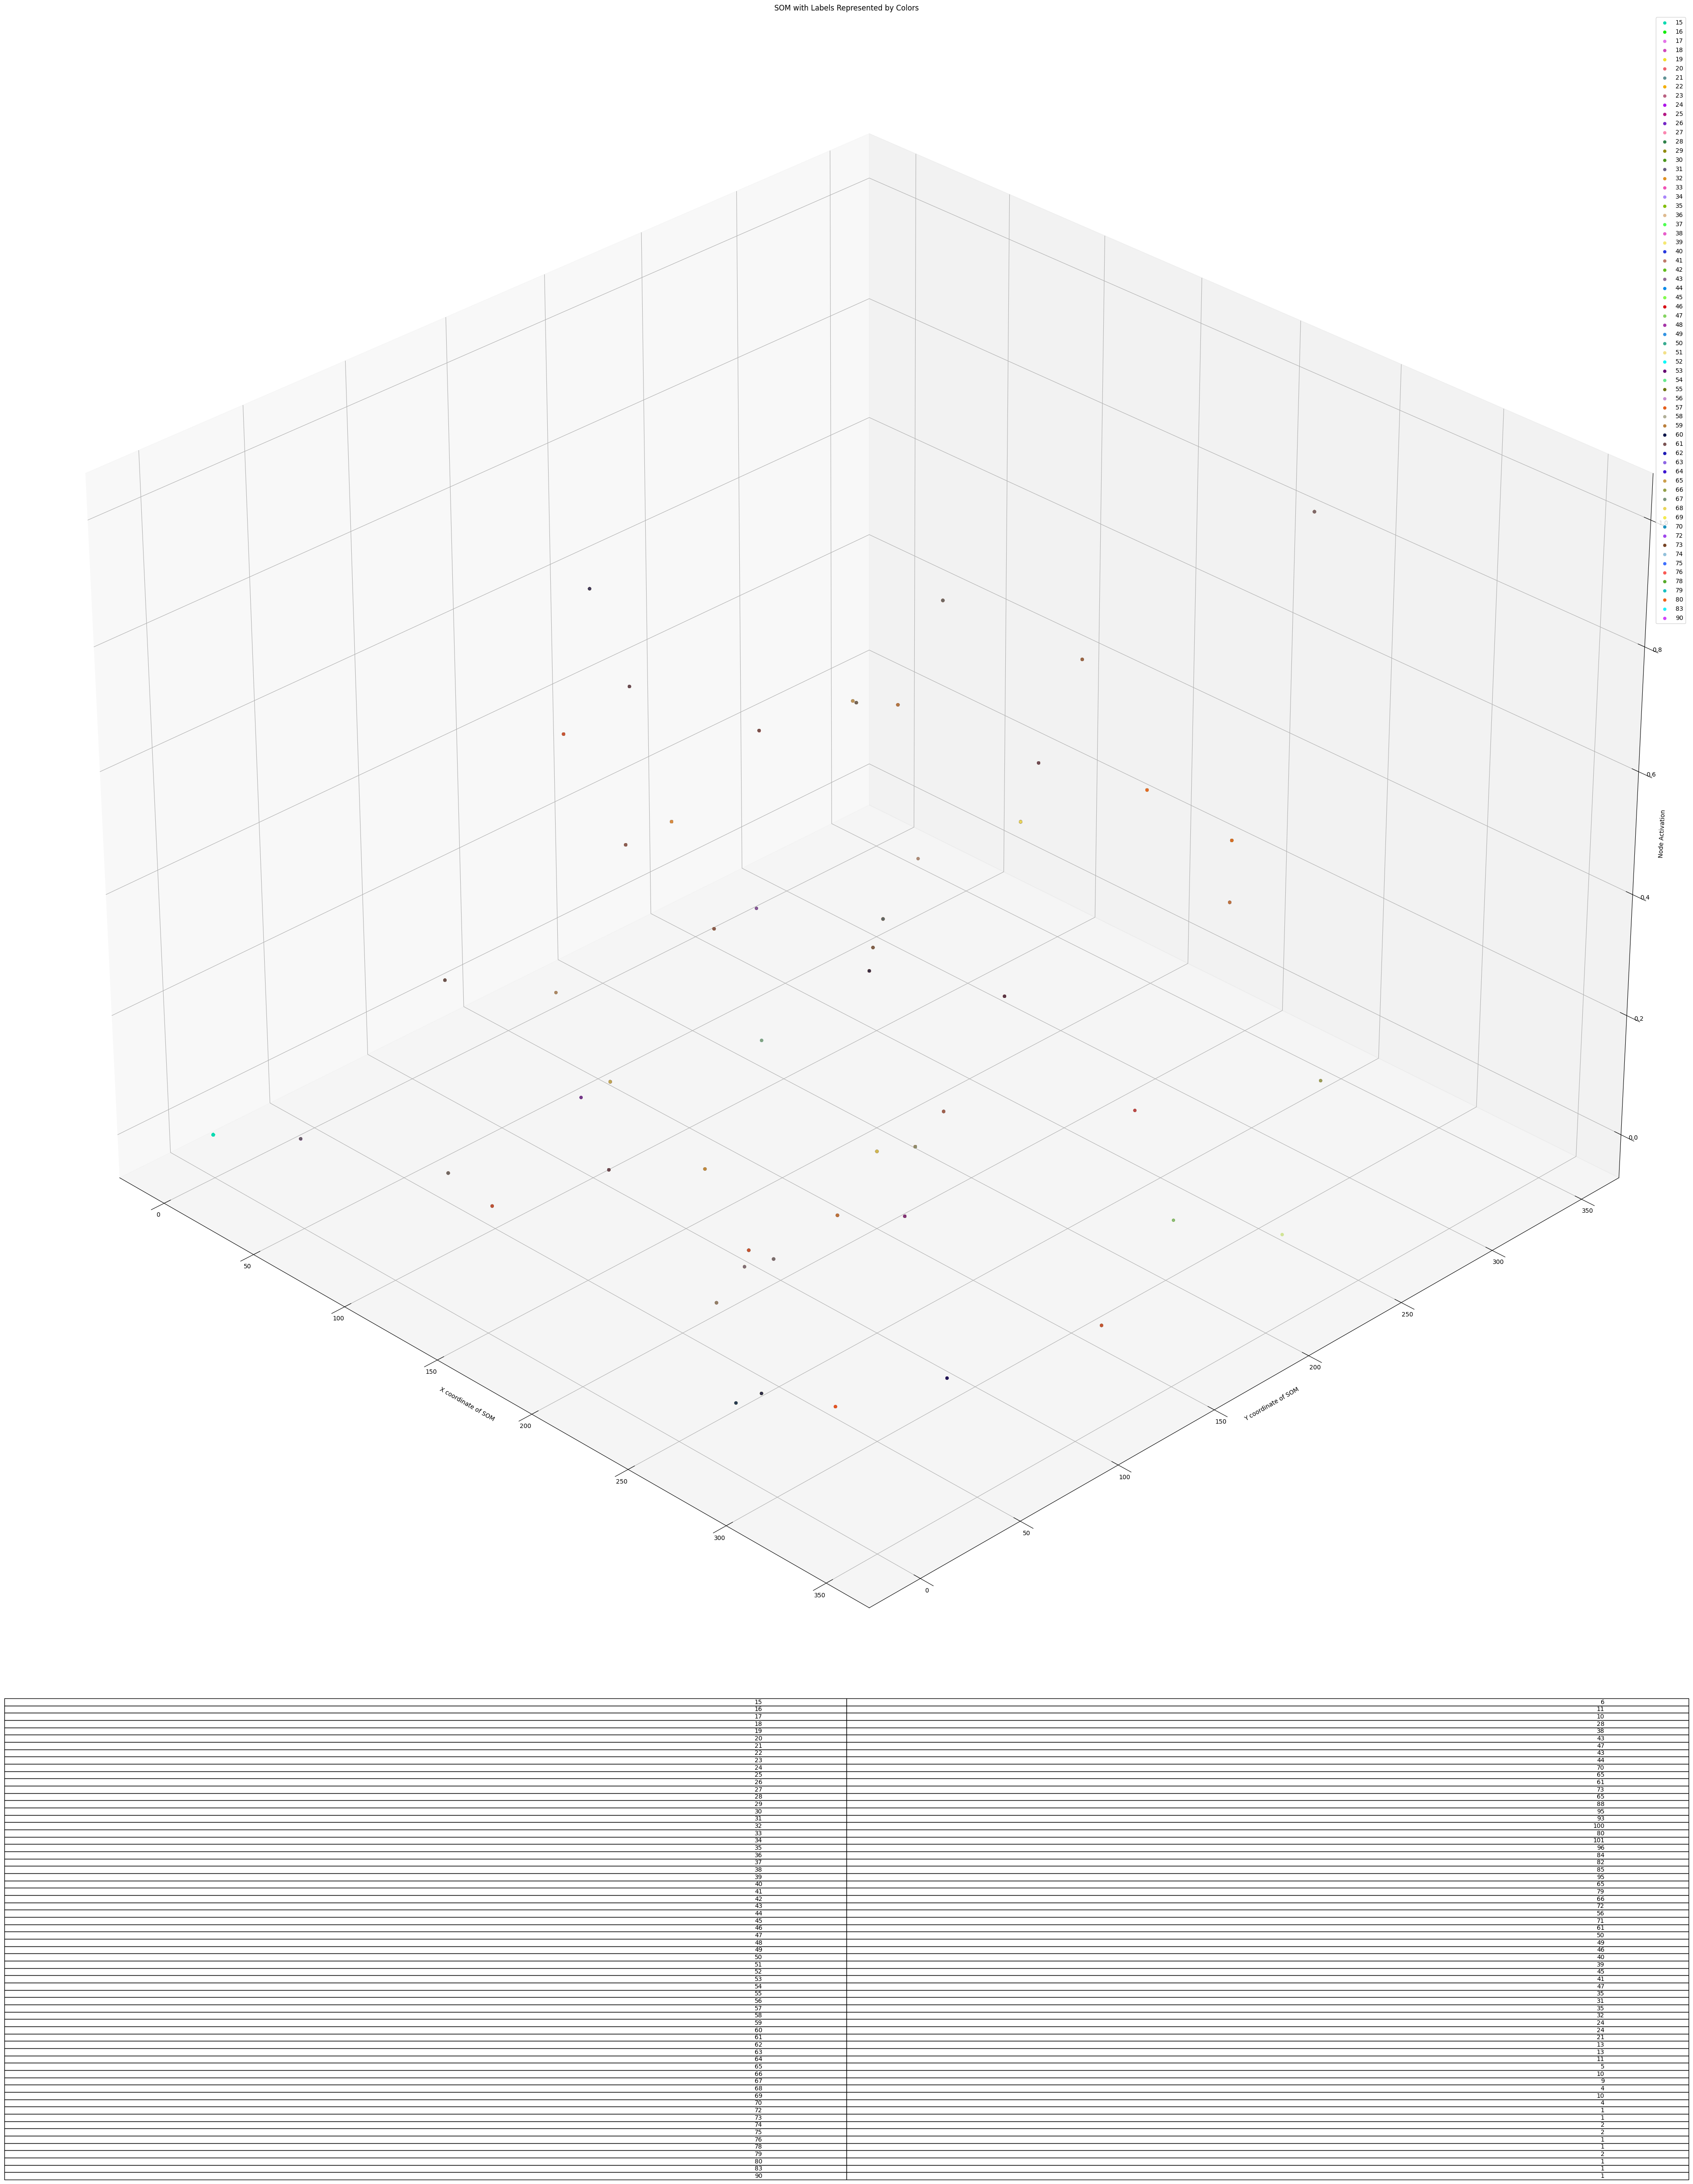

In [44]:
vals = make_3D_graph(som, X_f_cat1_live, Y_age, SOM_DIM)

purple 0.0
blue 1.0
green 2.0
yellow 3.0
orange 4.0
cyan 5.0
red 6.0
brown 7.0
gray 8.0
magenta 9.0
lime 10.0
pink 11.0
teal 12.0
bisque 13.0
tan 14.0
black 15.0
white 16.0
powderblue 17.0
rosybrown 18.0
peru 19.0
deeppink 20.0
mediumpurple 21.0
plum 22.0
deepskyblue 23.0
darkseagreen 24.0
tomato 25.0
cadetblue 26.0
beige 27.0
navy 28.0
palevioletred 29.0
gainsboro 30.0


KeyError: 31

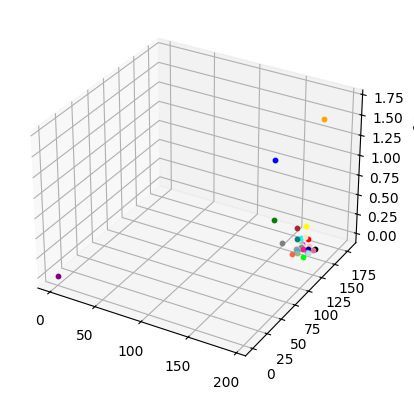

In [45]:
xyz = vals[:, :3]
labels = vals[:, 3]

unique_labels = np.unique(labels)

centers = []

# ---- Compute center (mean x,y,z) for each label ----
for lab in unique_labels:
    points = xyz[labels == lab]
    center = points.mean(axis=0)
    centers.append((lab, center))

centers = np.array([(lab, *center) for lab, center in centers])
# centers shape: (num_labels, 4) → (label, cx, cy, cz)

# ---- Plot ----
fig = plt.figure()
ax = plt.subplot(projection='3d')

# Plot centers
#ax.scatter(centers[:, 1], centers[:, 2], centers[:, 3], s=120, marker='o')

# Annotate each center with its label
idz = centers[:,3].argmax()
label_with_max_z = int(centers[idz, 0])
max_z = centers[idz, 3]
for row in centers:
    #lab, cx, cy, cz = row
    #ax.text(cx, cy, cz, str(int(lab)))
    lab, cx, cy, cz = row
    color = label_colors[int(lab)]
    print(color,lab)
    ax.scatter(cx, cy, cz**50, s=10, color=color)
    ax.text(cx, cy, cz, str(int(lab)))

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Cluster Centers by Label")

plt.show()

In [46]:
np.corrcoef(labels, xyz[:,2])[0,1]

0.4993551867708481

In [47]:
import scipy

scipy.stats.spearmanr(labels, xyz[:,2])

SignificanceResult(statistic=0.8286066826840718, pvalue=0.0)

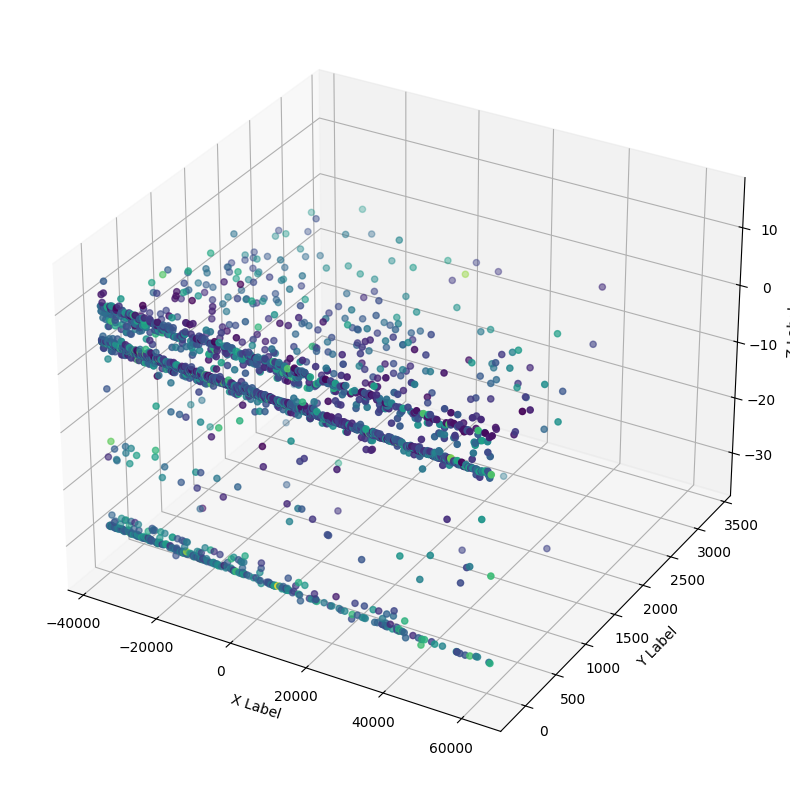

In [49]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_f_cat1_live)

fig1 = plt.figure(figsize=(10, 10))
ax1 = fig1.add_subplot(111, projection='3d')
ax1.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c = Y_age, marker='o')

# Set labels
ax1.set_xlabel('X Label')
ax1.set_ylabel('Y Label')
ax1.set_zlabel('Z Label')
plt.show()

tan 15.0
black 16.0
white 17.0
powderblue 18.0
rosybrown 19.0
peru 20.0
deeppink 21.0
mediumpurple 22.0
plum 23.0
deepskyblue 24.0
darkseagreen 25.0
tomato 26.0
cadetblue 27.0
beige 28.0
navy 29.0
palevioletred 30.0
gainsboro 31.0


KeyError: 31

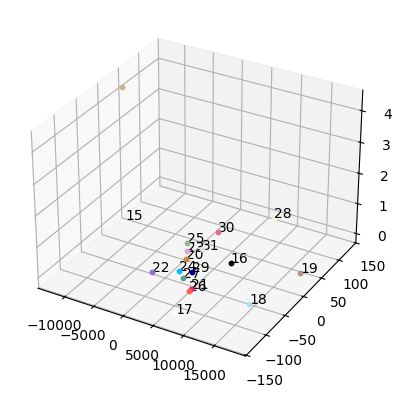

In [53]:
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_f_cat1_live)
xyz = X_pca[:, :3]
labels = Y_age

unique_labels = np.unique(labels)

centers = []

# ---- Compute center (mean x,y,z) for each label ----
for lab in unique_labels:
    points = xyz[labels == lab]
    center = points.mean(axis=0)
    centers.append((lab, center))

centers = np.array([(lab, *center) for lab, center in centers])
# centers shape: (num_labels, 4) → (label, cx, cy, cz)

# ---- Plot ----
fig = plt.figure()
ax = plt.subplot(projection='3d')

# Plot centers
#ax.scatter(centers[:, 1], centers[:, 2], centers[:, 3], s=120, marker='o')

# Annotate each center with its label
idz = centers[:,3].argmax()
label_with_max_z = int(centers[idz, 0])
max_z = centers[idz, 3]
for row in centers:
    #lab, cx, cy, cz = row
    #ax.text(cx, cy, cz, str(int(lab)))
    lab, cx, cy, cz = row
    color = label_colors[int(lab) - 1]
    print(color,lab)
    ax.scatter(cx, cy, cz**50, s=10, color=color)
    ax.text(cx, cy, cz, str(int(lab)))

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Cluster Centers by PCA")

plt.show()

In [59]:
cor0 = np.corrcoef(Y_age,X_pca[:,0])
cor1 = np.corrcoef(Y_age,X_pca[:,1])
cor2 = np.corrcoef(Y_age,X_pca[:,2])
cor3 = np.corrcoef(Y_age,X_pca[:,3])
cor4 = np.corrcoef(Y_age,X_pca[:,4])

print(cor0[0,1])
print(cor1[0,1])
print(cor2[0,1])
print(cor3[0,1])
print(cor4[0,1])
scipy.stats.spearmanr(Y_age, X_pca[:,2])

-0.07753415807010065
0.023228616381932802
-0.1656202876372025
-0.01245274017386268
-0.09787950194068838


SignificanceResult(statistic=-0.11157451133281904, pvalue=5.2559937605435805e-09)

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


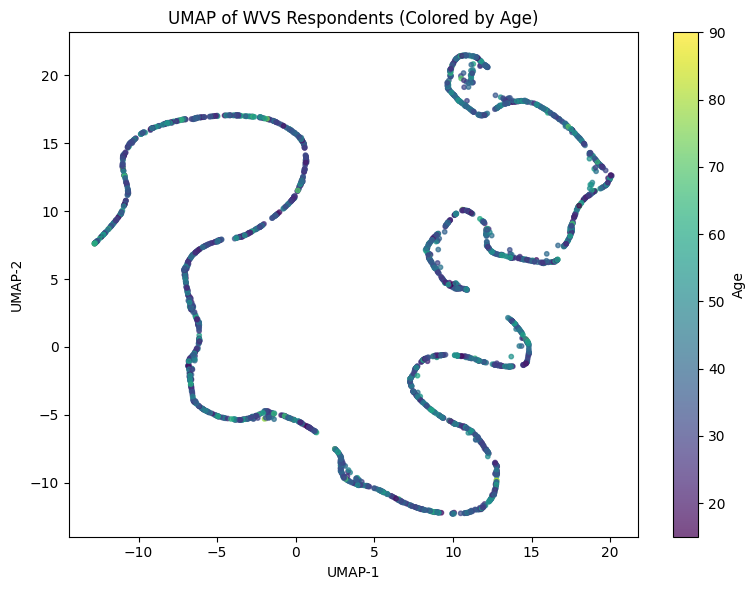

In [55]:
import umap
umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.2,
    n_components=2,
    metric='euclidean',
    random_state=42
)

embedding = umap_model.fit_transform(X_f_cat1_live)

plt.figure(figsize=(8, 6))

sc = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=Y_age,
    cmap='viridis',
    s=10,
    alpha=0.7
)

plt.colorbar(sc, label='Age')
plt.title('UMAP of WVS Respondents (Colored by Age)')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')

plt.tight_layout()
plt.show()

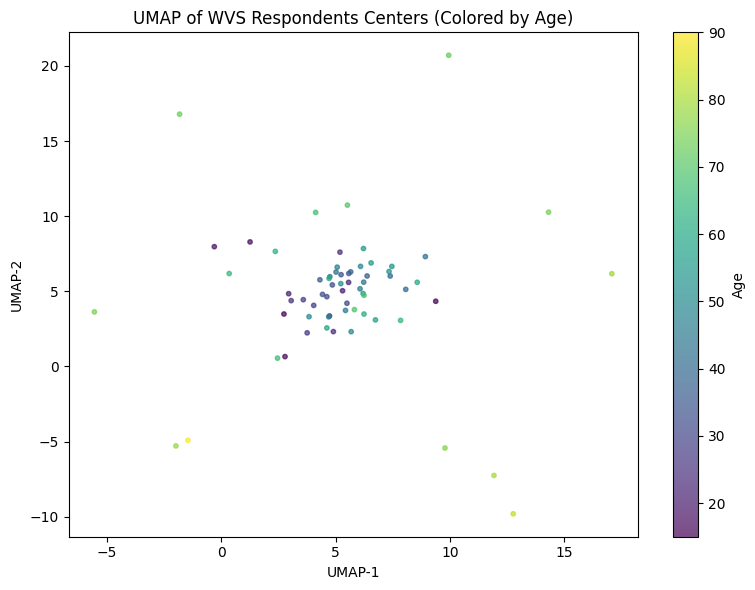

In [56]:
xyz = embedding
labels = Y_age

unique_labels = np.unique(labels)

centers = []

# ---- Compute center (mean x,y,z) for each label ----
for lab in unique_labels:
    points = xyz[labels == lab]
    center = points.mean(axis=0)
    centers.append((lab, center))

centers = np.array([(lab, *center) for lab, center in centers])
# centers shape: (num_labels, 4) → (label, cx, cy, cz)
plt.figure(figsize=(8, 6))

sc = plt.scatter(
    centers[:, 1],
    centers[:, 2],
    c=centers[:,0],
    cmap='viridis',
    s=10,
    alpha=0.7
)

plt.colorbar(sc, label='Age')
plt.title('UMAP of WVS Respondents Centers (Colored by Age)')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')

plt.tight_layout()
plt.show()

In [58]:
umap_cor0 = np.corrcoef(Y_age,embedding[:,0])
umap_cor1 = np.corrcoef(Y_age,embedding[:,1])
print(umap_cor0[0,1],umap_cor1[0,1])
scipy.stats.spearmanr(Y_age, embedding[:,0])

0.07715176029685429 0.01281290174137396


In [60]:
scipy.stats.spearmanr(Y_age, embedding[:,0])

SignificanceResult(statistic=0.08558086491454336, pvalue=7.72055888282089e-06)

In [68]:
for i in range(X_f_cat1_live.shape[1]):
    print(scipy.stats.spearmanr(Y_age, X_f_cat1_live[:,i]).statistic, np.corrcoef(Y_age,X_f_cat1_live[:,i])[0,1])

-0.005817100251449502 0.07745031177791802
nan nan
-0.14039684852919432 -0.1685890057874765
0.002702623742090129 -0.03033464275620494
0.27544998707324975 0.15743898779801146
0.04876494980758462 0.05435276298327886
0.01403739057953278 0.006013341249687437
-0.09337944206523086 -0.07515568414816738
nan nan
nan nan
-0.20480469164900136 -0.10487498632202806
-0.1859714792550187 -0.11741929413862724
-0.09893873990455107 -0.07753405192152783
-0.16180762770324938 -0.14777745242929693
-0.0334897086294856 -0.0027255356064314175
-0.02894150117819701 0.024493175623541547


/var/folders/sl/vnf426s55n5b1nyg0gf3qr4r0000gn/T/ipykernel_47407/3392429140.py:2: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  print(scipy.stats.spearmanr(Y_age, X_f_cat1_live[:,i]).statistic, np.corrcoef(Y_age,X_f_cat1_live[:,i])[0,1])


In [5]:
Y_nat = []
for i in range(len(Y_f_cat1_live)):
    if Y_f_cat1_live[i] == Y_f_cat1_live[0]:
        Y_nat.append(0)
    else:
        Y_nat.append(1)

Y_nat = np.array(Y_nat)

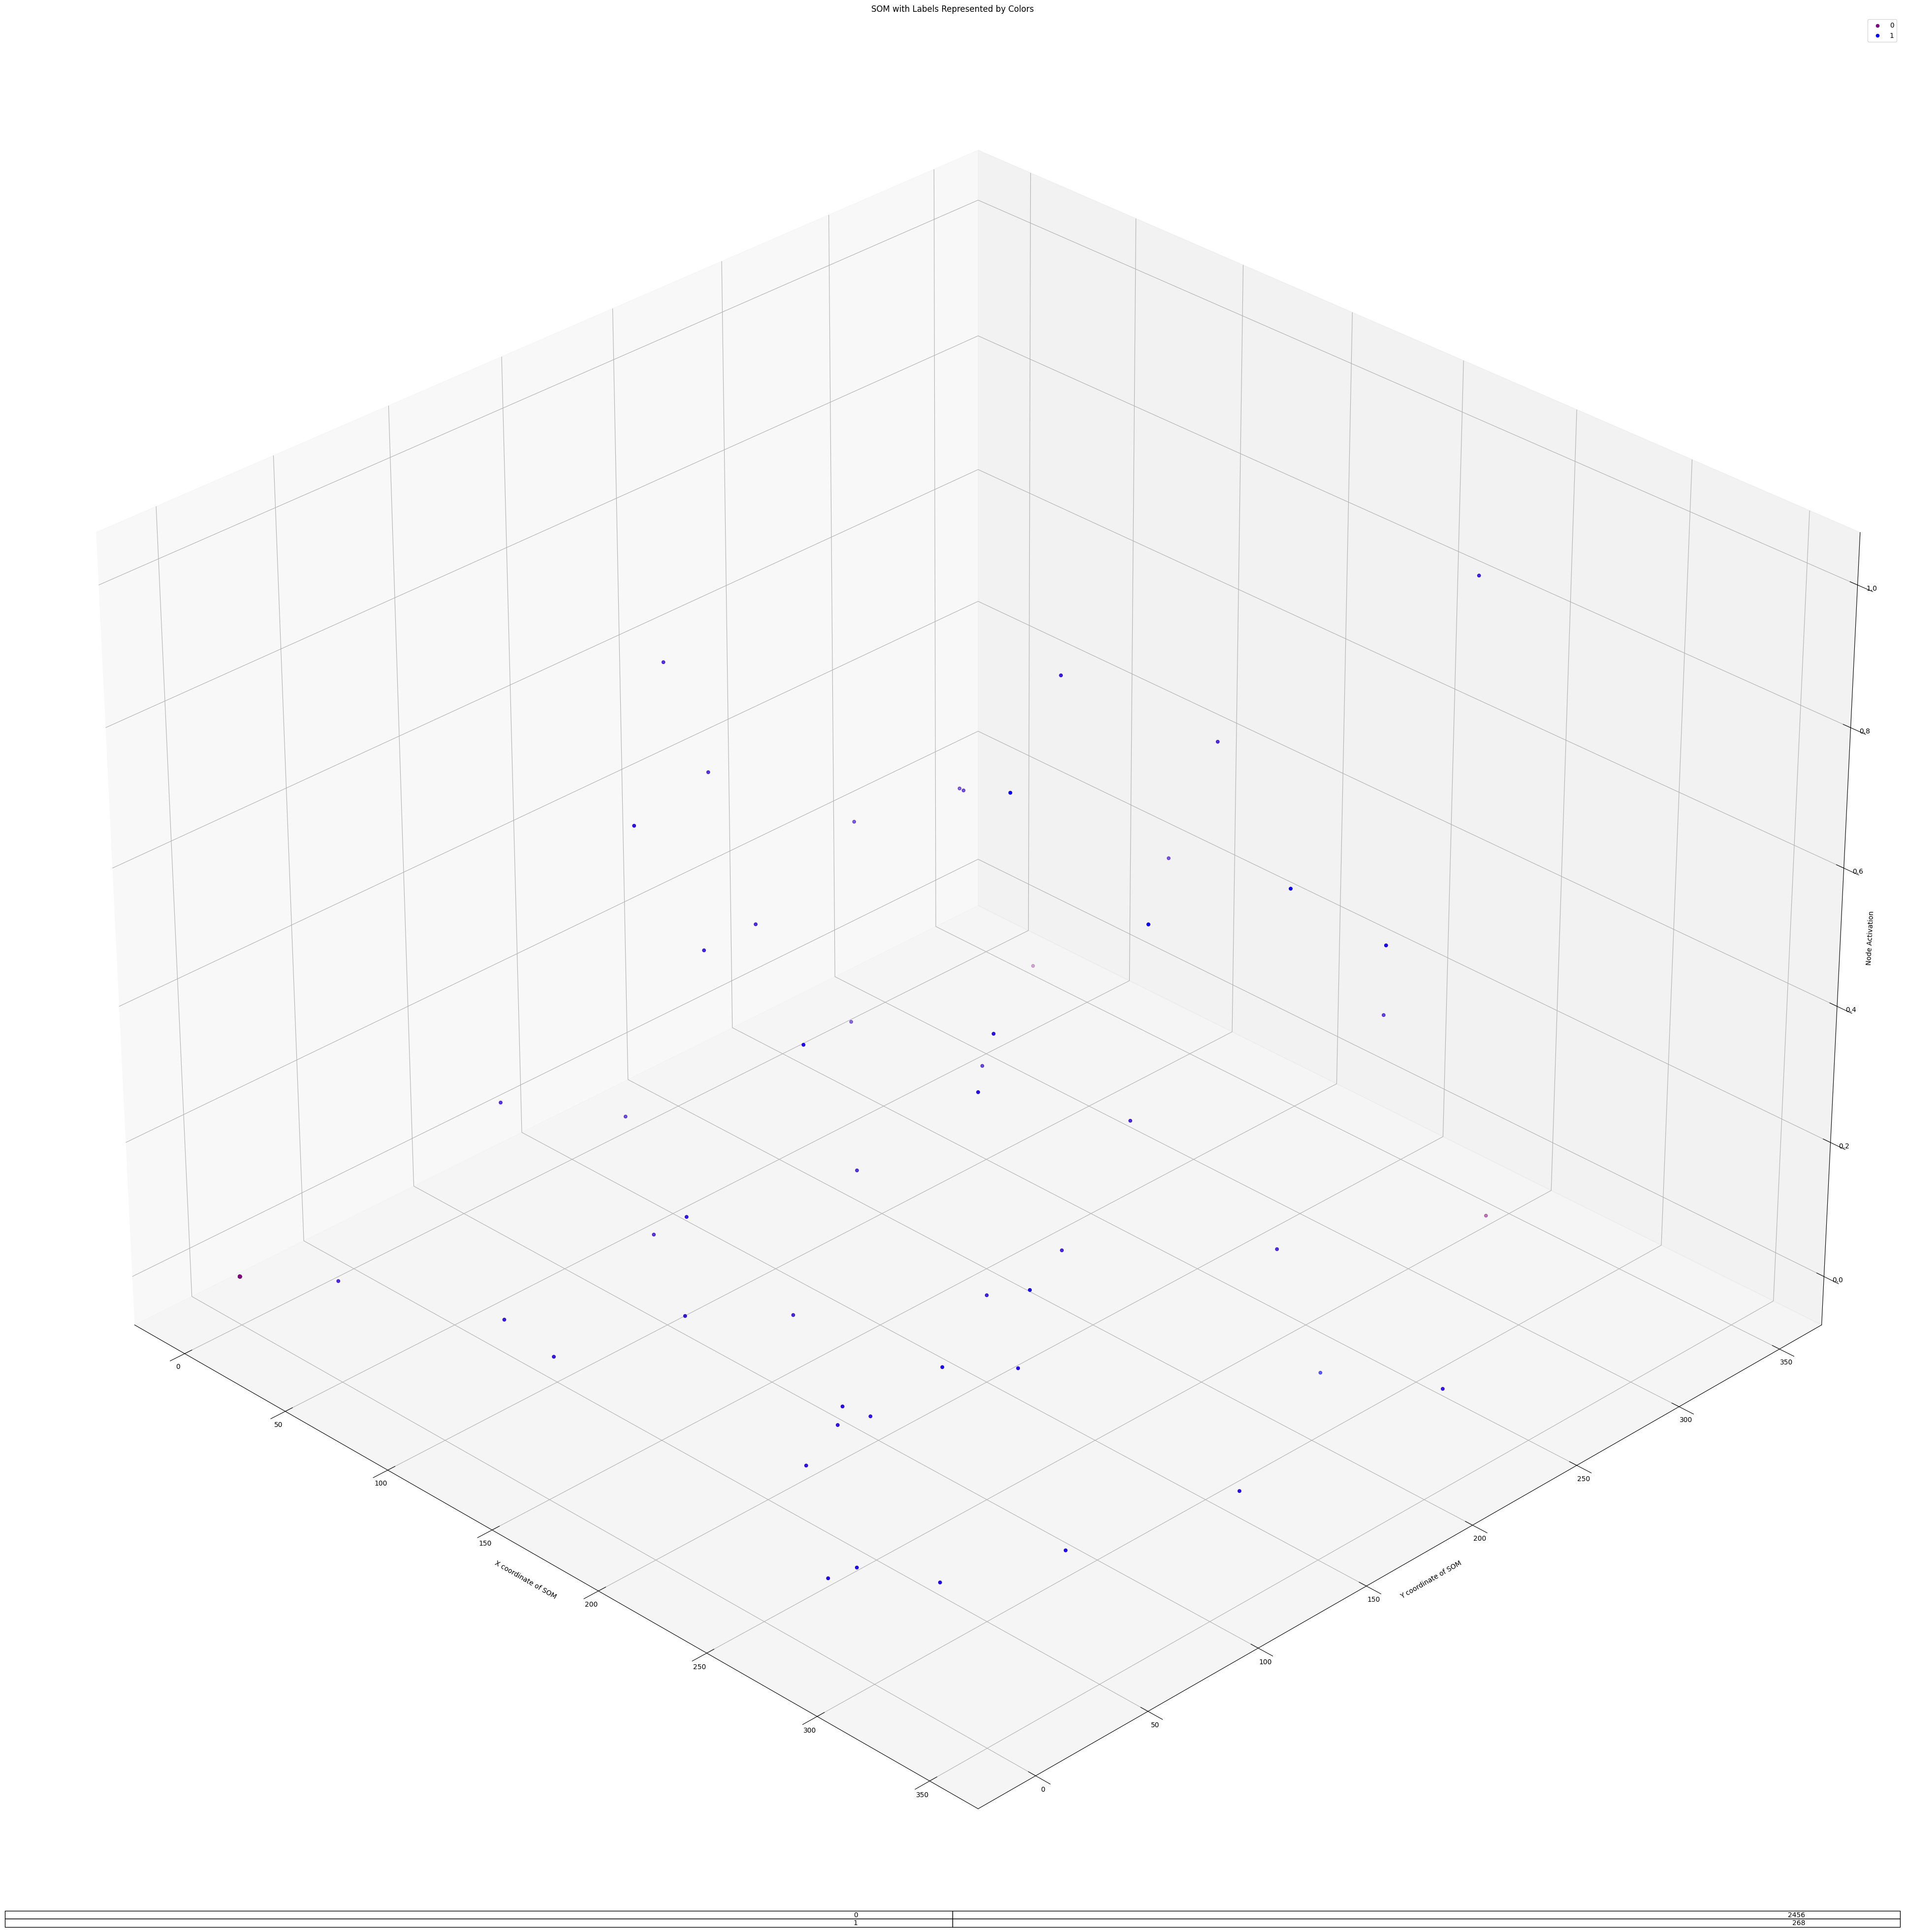

In [92]:
vals = make_3D_graph(som, X_f_cat1_live, Y_nat, SOM_DIM)

purple 0.0
blue 1.0


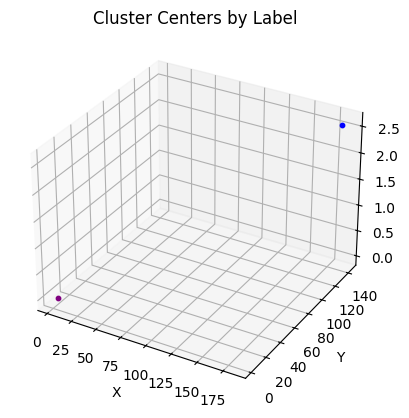

In [93]:
xyz = vals[:, :3]
labels = vals[:, 3]

unique_labels = np.unique(labels)

centers = []

# ---- Compute center (mean x,y,z) for each label ----
for lab in unique_labels:
    points = xyz[labels == lab]
    center = points.mean(axis=0)
    centers.append((lab, center))

centers = np.array([(lab, *center) for lab, center in centers])
# centers shape: (num_labels, 4) → (label, cx, cy, cz)

# ---- Plot ----
fig = plt.figure()
ax = plt.subplot(projection='3d')

# Plot centers
#ax.scatter(centers[:, 1], centers[:, 2], centers[:, 3], s=120, marker='o')

# Annotate each center with its label
idz = centers[:,3].argmax()
label_with_max_z = int(centers[idz, 0])
max_z = centers[idz, 3]
for row in centers:
    #lab, cx, cy, cz = row
    #ax.text(cx, cy, cz, str(int(lab)))
    lab, cx, cy, cz = row
    color = label_colors[int(lab)]
    print(color,lab)
    ax.scatter(cx, cy, cz**50, s=10, color=color)
    ax.text(cx, cy, cz, str(int(lab)))

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Cluster Centers by Label")

plt.show()

In [94]:
np.corrcoef(labels, xyz[:,2])[0,1]

0.4806354020629787

In [95]:
scipy.stats.spearmanr(labels, xyz[:,2])

SignificanceResult(statistic=0.6968120287844043, pvalue=0.0)

In [100]:
cor0 = np.corrcoef(Y_nat,X_pca[:,0])
cor1 = np.corrcoef(Y_nat,X_pca[:,1])
cor2 = np.corrcoef(Y_nat,X_pca[:,2])
cor3 = np.corrcoef(Y_nat,X_pca[:,3])
cor4 = np.corrcoef(Y_nat,X_pca[:,4])

print(cor0[0,1])
print(cor1[0,1])
print(cor2[0,1])
print(cor3[0,1])
print(cor4[0,1])
scipy.stats.spearmanr(Y_nat, X_pca[:,2])

-0.07947253316784751
-0.003074067467524708
-0.31394440695241277
-0.03595959681806998
-0.03785569022583367


SignificanceResult(statistic=-0.20642926086932278, pvalue=1.3374337541109036e-27)

In [101]:
umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.2,
    n_components=2,
    metric='euclidean',
    random_state=42
)

embedding = umap_model.fit_transform(X_f_cat1_live)


/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [102]:
umap_cor0 = np.corrcoef(Y_nat,embedding[:,0])
umap_cor1 = np.corrcoef(Y_nat,embedding[:,1])
print(umap_cor0[0,1],umap_cor1[0,1])

0.07277094197464741 0.011313125678122055


In [103]:
scipy.stats.spearmanr(Y_nat, embedding[:,0])

SignificanceResult(statistic=0.07387219107302143, pvalue=0.00011383438135221793)

In [6]:
Y_gains_f = x.to_numpy()[X[:,11 - 1] == 1]
Y_gains_f_cat1 = Y_gains_f[X_f[:,7 - 1] == 1]
Y_gains_f_cat1_live = Y_gains_f_cat1[X_f_cat1[:,27 - 11] == 0]
Y_gains = Y_gains_f_cat1_live[:,15]
print(Y_gains.shape)


(2724,)


In [144]:
maps = som.distance_map()
labels_map = som.labels_map(X_f_cat1_live, Y_gains)
mapped = 0
points = np.zeros((Y_gains.shape[0], 3))
for x in range(SOM_DIM):
    for y in range(SOM_DIM):
        label_list = labels_map.get((x, y), [])
        if label_list:
            for label in list(label_list.keys()):

                points[mapped] = [x,y,maps[x][y]]
                mapped += 1

        

In [ ]:
Y_gains = np.reshape(Y_gains, ((2724,1)))
for g in range(len(Y_gains)):
    Y_gains[g] = Y_gains[g][0]

In [167]:
pts = np.reshape(points[:,2], ((2724,1)))

In [179]:
umap_cor0 = np.corrcoef(Y_gains.transpose(),embedding[:,0])
umap_cor1 = np.corrcoef(Y_gains.transpose(),embedding[:,1])
print(umap_cor0[0,1],umap_cor1[0,1])
scipy.stats.spearmanr(Y_gains, embedding[:,0])

AttributeError: 'float' object has no attribute 'shape'

In [181]:
'''
cor0 = np.corrcoef(Y_gains,X_pca[:,0])
cor1 = np.corrcoef(Y_age,X_pca[:,1])
cor2 = np.corrcoef(Y_age,X_pca[:,2])
cor3 = np.corrcoef(Y_age,X_pca[:,3])
cor4 = np.corrcoef(Y_age,X_pca[:,4])

print(cor0[0,1])
print(cor1[0,1])
print(cor2[0,1])
print(cor3[0,1])
print(cor4[0,1])
'''
scipy.stats.spearmanr(Y_age, X_pca[:,2])

SignificanceResult(statistic=-0.11157451133281904, pvalue=5.2559937605435805e-09)

In [185]:
scipy.stats.spearmanr(Y_age, Y_gains)

SignificanceResult(statistic=0.0791812999360481, pvalue=3.515286290056651e-05)

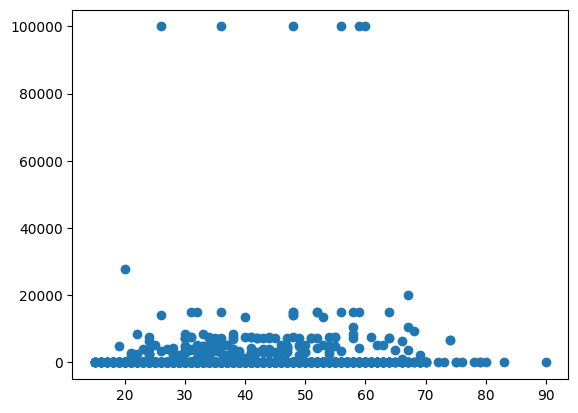

In [184]:
plt.scatter(Y_age, Y_gains)
plt.show()

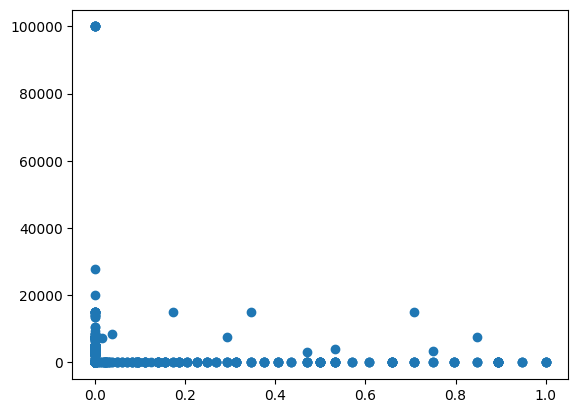

In [186]:
plt.scatter(pts, Y_gains)
plt.show()

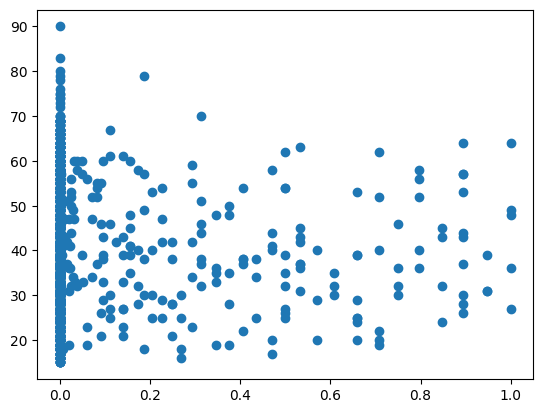

In [187]:
plt.scatter(pts, Y_age)
plt.show()

In [ ]:
import numpy as np
a =[-0.005817100251449502,-0.14039684852919432,0.002702623742090129,0.27544998707324975, 0.04876494980758462, 0.01403739057953278, -0.09337944206523086, -0.20480469164900136, -0.1859714792550187,-0.09893873990455107,-0.16180762770324938,-0.0334897086294856,-0.02894150117819701]
a = np.array(a)
print(a.max(), a.mean())


In [40]:
b = []

#print(Y_gains.shape)
print(type(X_f_cat1_live[:,i][0]))
for i in range(X_f_cat1_live.shape[1]):
    temp = np.corrcoef(Y_nat,X_f_cat1_live[:,i])[0][1]
    if not np.isnan(temp):
        b.append(np.corrcoef(Y_nat,X_f_cat1_live[:,i])[0][1])
b = np.array(b)
print(b.max(), b.mean())

<class 'numpy.int64'>
0.12170435692063618 -0.03935697047496988


In [14]:
import scipy
from sklearn.manifold import TSNE
import umap
from sklearn.decomposition import PCA
def compare(X,Y):
    comps = 16
    all_cors = []
    pca = PCA(n_components=comps)
    X_pca = pca.fit_transform(X)
    print("PCA's calc'ed")
    p_max_cor = 0
    p_max_cor_ind = 0
    for i in range(comps):
        cor = np.corrcoef(Y,X_pca[:,i])[0,1]
        if abs(p_max_cor) < abs(cor):
            p_max_cor = cor
            p_max_cor_ind = i
    p_sp = scipy.stats.spearmanr(Y, X_pca[:,p_max_cor_ind])
    all_cors.append((p_max_cor, p_sp.statistic, p_sp.pvalue))
    print("PCA stats calc'ed")
    del pca, X_pca
    global umap
    umap_model = umap.UMAP(n_components=comps, n_neighbors=comps,min_dist=0.2,metric='euclidean',random_state=2)
    X_umap = umap_model.fit_transform(X)
    #print(X_umap.shape)
    print("UMAP calc'ed")
    u_max_cor = 0
    u_max_cor_ind = 0
    for i in range(comps):
        cor = np.corrcoef(Y,X_umap[:,i])[0,1]
        if abs(u_max_cor) < abs(cor):
            u_max_cor = cor
            u_max_cor_ind = i
    u_sp = scipy.stats.spearmanr(Y, X_umap[:,u_max_cor_ind])
    all_cors.append((u_max_cor, u_sp.statistic, u_sp.pvalue))
    print("UMAP stats calc'ed")
    del umap_model, X_umap
    tsne = TSNE(n_components=3, random_state=2, perplexity=30)
    X_tsne = tsne.fit_transform(X)
    print("TSNE calc'ed")
    t_max_cor = 0
    t_max_cor_ind = 0
    for i in range(3):
        cor = np.corrcoef(Y,X_tsne[:,i])[0,1]
        if abs(t_max_cor) < abs(cor):
            t_max_cor = cor
            t_max_cor_ind = i
    t_sp = scipy.stats.spearmanr(Y, X_tsne[:,t_max_cor_ind])
    all_cors.append((t_max_cor, t_sp.statistic, t_sp.pvalue))
    print(all_cors)
    return all_cors

In [16]:
#compare(X_f_cat1_live,Y_age)
compare(X_f_cat1_live,Y_nat)
compare(X_f_cat1_live,Y_gains)

PCA's calc'ed
PCA stats calc'ed


/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP calc'ed
UMAP stats calc'ed
TSNE calc'ed
[(-0.31394440695241277, -0.20642926086932278, 1.3374337541109036e-27), (-0.07332278752411629, -0.07307120886205737, 0.00013503927406941754), (-0.07602059460900905, -0.07844923229017395, 4.151948236663809e-05)]
PCA's calc'ed


AttributeError: 'float' object has no attribute 'shape'